CRIM - per capita crime rate by town

ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS - proportion of non-retail business acres per town.

CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX - nitric oxides concentration (parts per 10 million)

RM - average number of rooms per dwelling

AGE - proportion of owner-occupied units built prior to 1940

DIS - weighted distances to five Boston employment centres

RAD - index of accessibility to radial highways

TAX - full-value property-tax rate per 10,000

PTRATIO - pupil-teacher ratio by town

B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

LSTAT - per lower status of the population

MEDV - Median value of owner-occupied homes in $1000's

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('HousingData.csv')
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
print(data.isnull().sum(axis=0))

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [6]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [7]:
data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: >

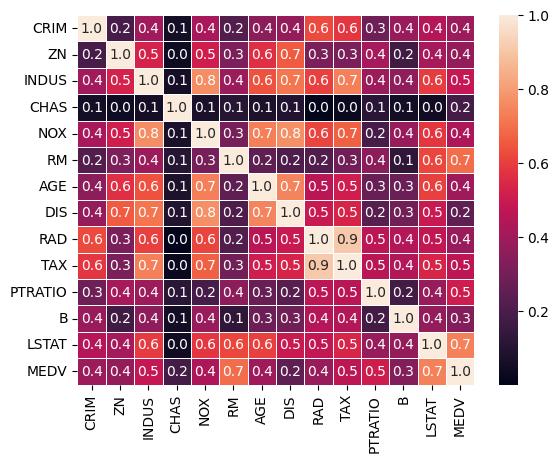

In [327]:
corr_matrix=data.corr()
sns.heatmap(np.abs(corr_matrix),fmt=".1f",annot=True,linewidth=.5)

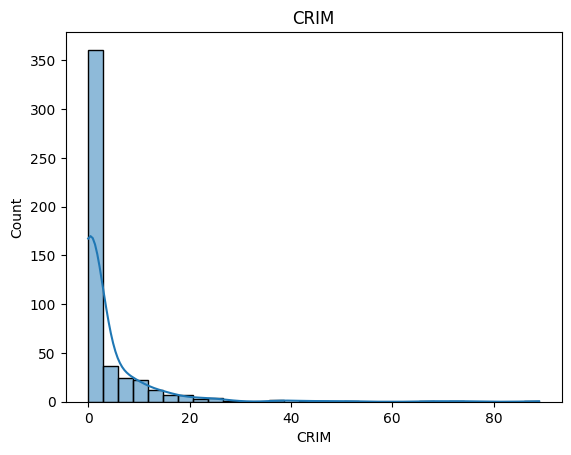

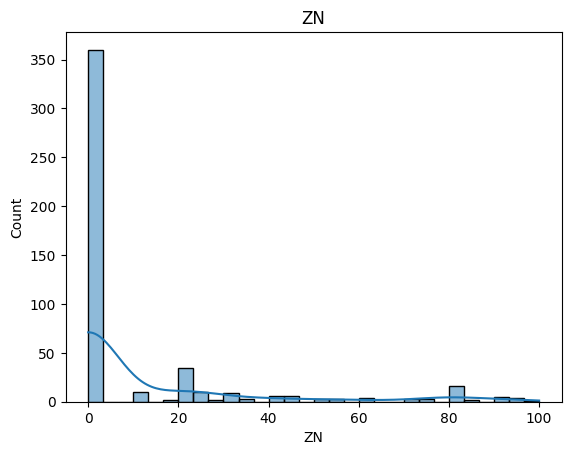

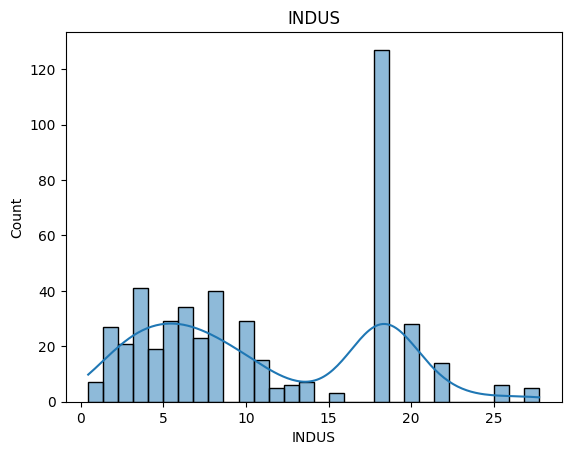

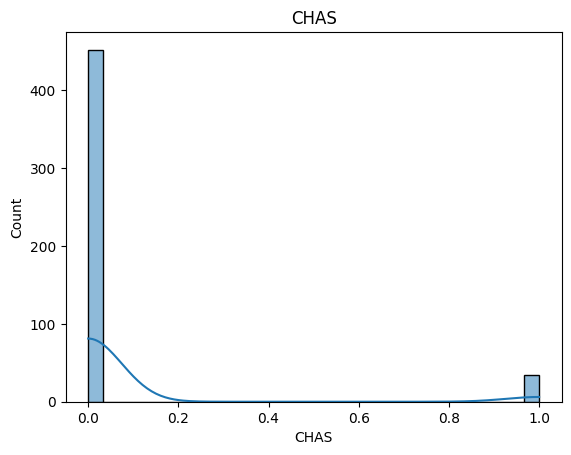

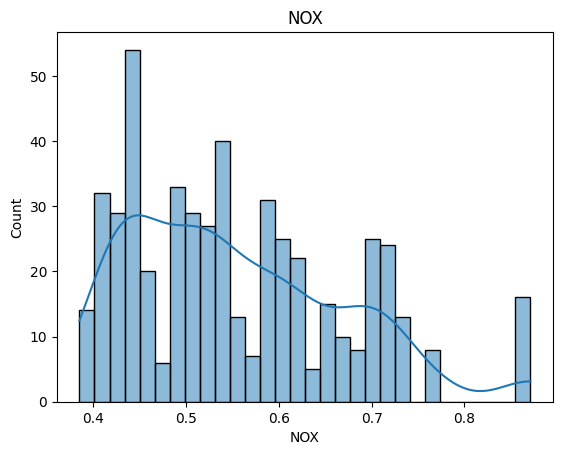

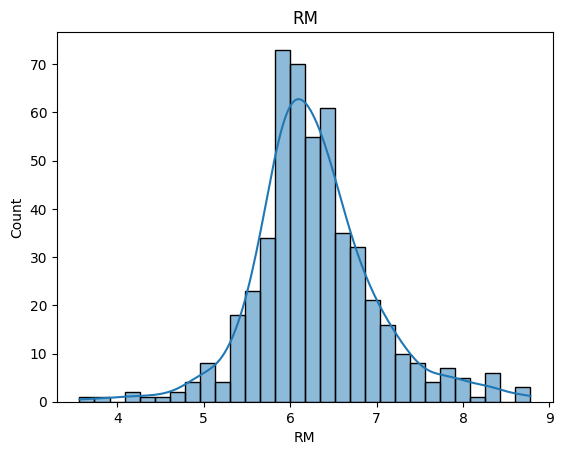

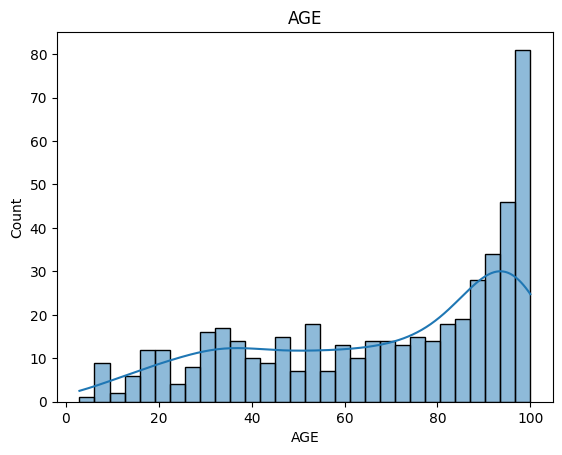

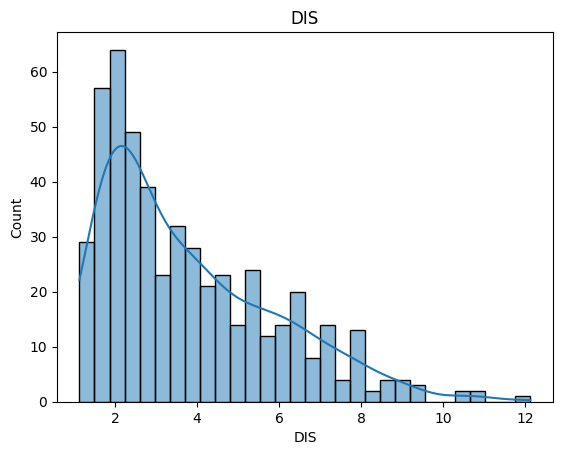

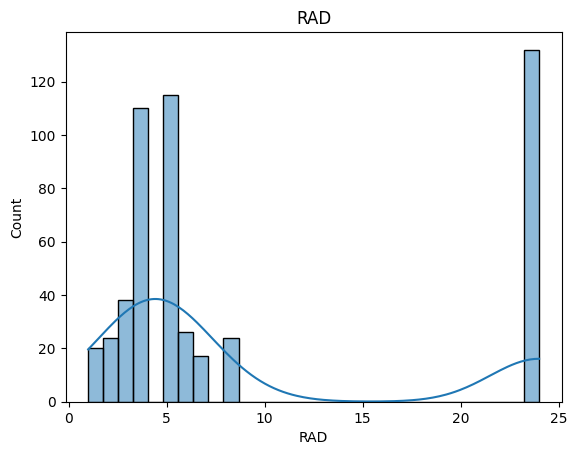

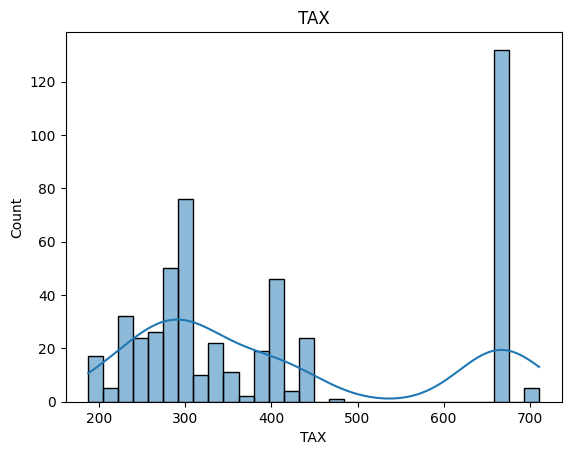

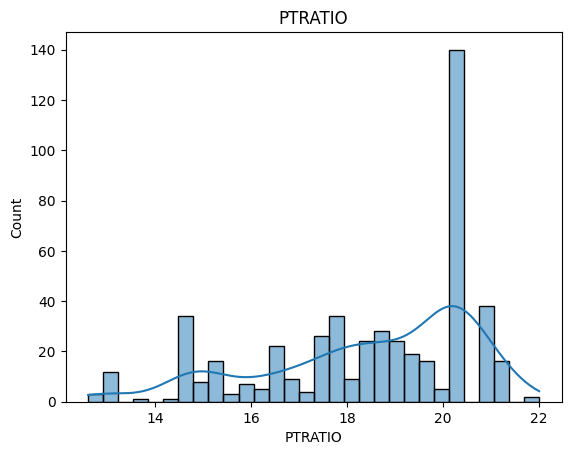

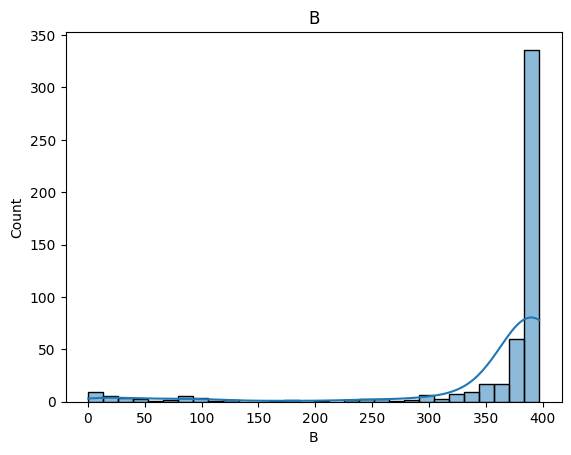

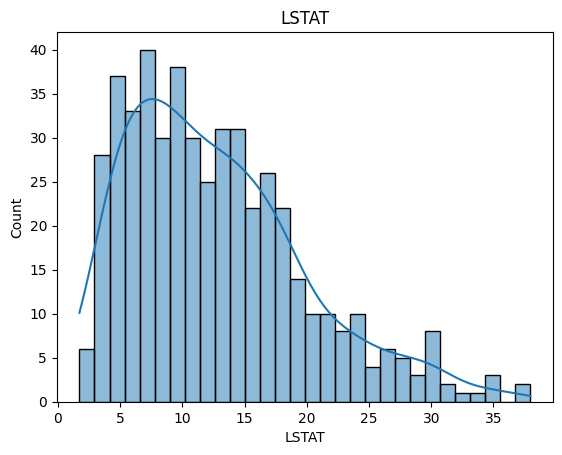

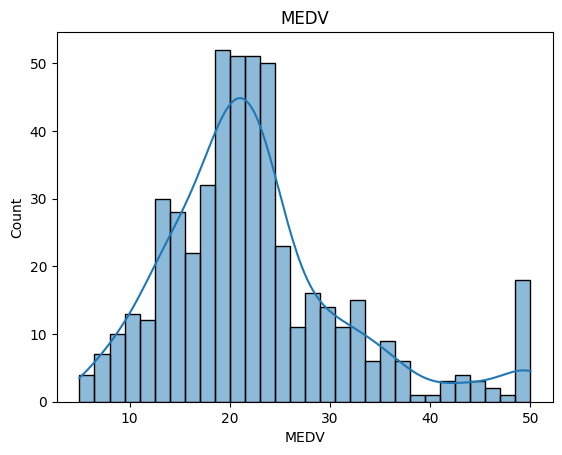

In [328]:
cols = data.columns

for col in cols:
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

In [329]:
# Using Median to handle missing values
skewed_features = ['CRIM', 'ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']

# Using Mean to handle missing values
normal_features = ['RM']

# Using Mode to handle missing values
categorical_features = ['CHAS']


for col in skewed_features:
    data[col] = data[col].fillna(data[col].median())

for col in normal_features:
    data[col] = data[col].fillna(data[col].mean())

for col in categorical_features:
    data[col] = data[col].fillna(data[col].mode()[0])

print("Missing Values after imputation")
data.isnull().sum()

Missing Values after imputation


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [330]:
cols_to_log = ['CRIM', 'LSTAT', 'DIS', 'NOX', 'RAD', 'TAX', 'INDUS']
df_clean[cols_to_log] = np.log1p(df_clean[cols_to_log])

In [331]:
# Checking Outliers
cols_to_exclude = ['CHAS', 'MEDV', 'ZN']
features_to_clean = [col for col in data.columns if col not in cols_to_exclude]
print(features_to_clean)

['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [332]:
def outlier_detection(df, features, mode='none'):
    """
        Options for mode:
            'none': Just check for outliers
            'cap': performs capping on outliers
            'remove': performs removal of outliers
    """

    df_processed = df.copy()
    total_outlier_values_count = 0
    rows_with_outliers = set()

    print(f'Starting Outlier Detection (Mode: {mode})...\n')

    for col in features:
        # 1. Calculating IQR Bounds
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 2. Discovering Outliers (for statistics only)
        current_outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
        num_outliers = len(current_outliers)

        if num_outliers > 0:
            percentage = (num_outliers / len(df_processed)) * 100
            print(f'Column: {col} | Outliers: {num_outliers} | {percentage:.2f}%')
            print(f'   -> Bounds: ({lower_bound:.2f}, {upper_bound:.2f})') # Useful to know what values ​​have changed

            total_outlier_values_count += num_outliers
            rows_with_outliers.update(current_outliers.index)

            # 3. Applying Capping (if the mode is cap)
            if mode == 'cap':
                # Any value less than lower will be lower, and any value greater than upper will be upper
                df_processed[col] = df_processed[col].clip(lower=lower_bound, upper=upper_bound)
    
    # Final Summary
    print('\n======= Final Summary =======')
    print(f'Total outlier values found: {total_outlier_values_count}')
    print(f'Unique rows affected: {len(rows_with_outliers)}')
    print(f'Rows percentage: {(len(rows_with_outliers)/len(df))*100:.2f}%')

    # 4. Apply the delete (if the mod is remove)
    if mode == 'remove':
        print('-> Removing rows with outliers...')
        df_processed = df_processed.drop(index=rows_with_outliers)
    elif mode == 'cap':
        print('-> Outliers have been capped to upper/lower bounds.')
    
    return df_processed


In [333]:
outlier_detection(data, features_to_clean)

Starting Outlier Detection (Mode: none)...

Column: CRIM | Outliers: 81 | 16.01%
   -> Bounds: (-4.00, 6.90)
Column: RM | Outliers: 30 | 5.93%
   -> Bounds: (4.78, 7.73)
Column: DIS | Outliers: 5 | 0.99%
   -> Bounds: (-2.53, 9.82)
Column: PTRATIO | Outliers: 15 | 2.96%
   -> Bounds: (13.20, 24.40)
Column: B | Outliers: 77 | 15.22%
   -> Bounds: (344.11, 427.50)
Column: LSTAT | Outliers: 12 | 2.37%
   -> Bounds: (-6.78, 30.58)

======= Final Summary =======
Total outlier values found: 220
Unique rows affected: 163
Rows percentage: 32.21%


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,11.43,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


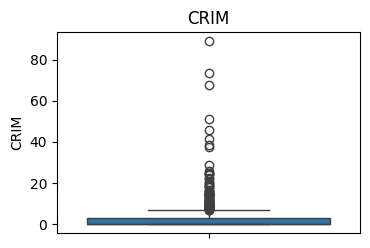

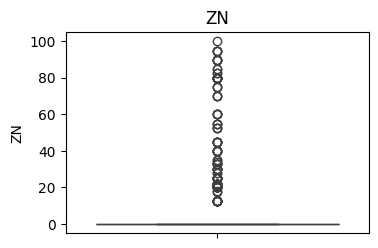

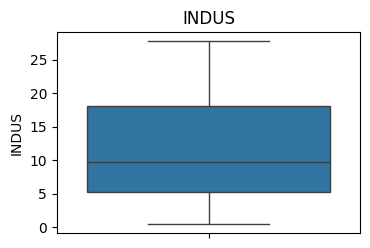

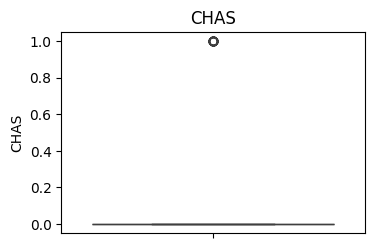

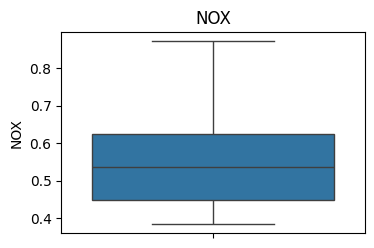

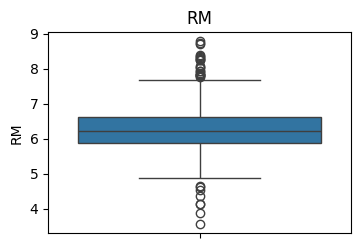

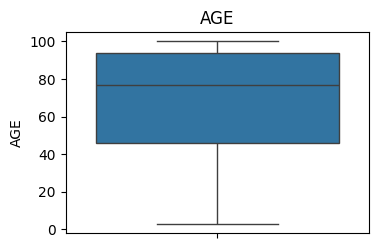

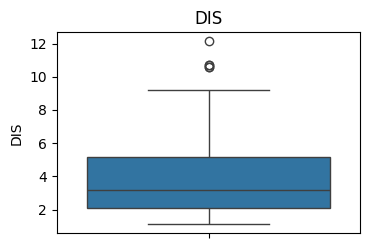

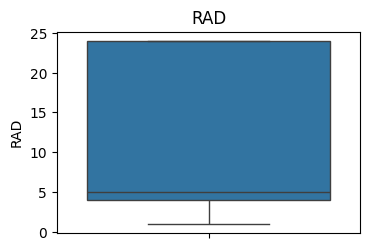

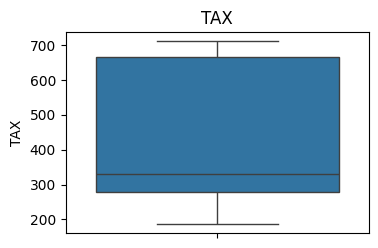

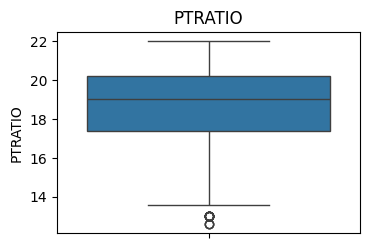

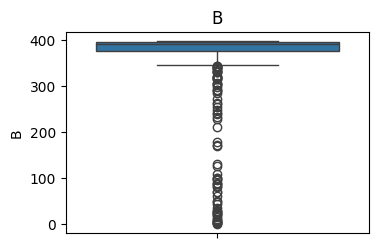

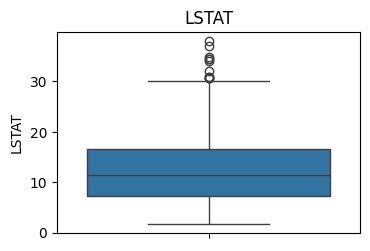

In [334]:
for i in range(len(data.columns) - 1):
    plt.figure(figsize=(18, 12))
    plt.subplot(4, 4, i+1)
    sns.boxplot(data.iloc[:, i])
    plt.title(f'{data.columns[i]}')
    plt.show()



In [335]:
df_clean = outlier_detection(data, features_to_clean, 'cap')

Starting Outlier Detection (Mode: cap)...

Column: CRIM | Outliers: 81 | 16.01%
   -> Bounds: (-4.00, 6.90)
Column: RM | Outliers: 30 | 5.93%
   -> Bounds: (4.78, 7.73)
Column: DIS | Outliers: 5 | 0.99%
   -> Bounds: (-2.53, 9.82)
Column: PTRATIO | Outliers: 15 | 2.96%
   -> Bounds: (13.20, 24.40)
Column: B | Outliers: 77 | 15.22%
   -> Bounds: (344.11, 427.50)
Column: LSTAT | Outliers: 12 | 2.37%
   -> Bounds: (-6.78, 30.58)

======= Final Summary =======
Total outlier values found: 220
Unique rows affected: 163
Rows percentage: 32.21%
-> Outliers have been capped to upper/lower bounds.


In [336]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,1.810211,2.623892,0.00632,0.083235,0.253715,2.808720,6.896948
ZN,506.0,10.768775,23.025124,0.00000,0.000000,0.000000,0.000000,100.000000
INDUS,506.0,11.028893,6.704679,0.46000,5.190000,9.690000,18.100000,27.740000
CHAS,506.0,0.067194,0.250605,0.00000,0.000000,0.000000,0.000000,1.000000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.871000
RM,506.0,6.275312,0.630242,4.77850,5.885500,6.208500,6.623500,7.730500
AGE,506.0,68.845850,27.486962,2.90000,45.925000,76.800000,93.575000,100.000000
DIS,506.0,3.783947,2.069765,1.12960,2.100175,3.207450,5.188425,9.820800
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.000000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.000000


In [337]:
x = df_clean.drop(columns=['MEDV'], axis=1)
y = df_clean['MEDV']

In [338]:
from sklearn.model_selection import train_test_split

In [339]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [340]:
print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

x_train shape:  (404, 13)
x_test shape:  (102, 13)
y_train shape:  (404,)
y_test shape:  (102,)


In [341]:
from sklearn.preprocessing import StandardScaler

cols_for_scaling = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Initialize StandardScaler
stand_scaler = StandardScaler()

# Fit the scaler on x_train and transform both x_train and x_test
x_train[cols_for_scaling] = stand_scaler.fit_transform(x_train[cols_for_scaling])
x_test[cols_for_scaling] = stand_scaler.transform(x_test[cols_for_scaling])

# WITH SKLEARN

In [342]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

In [343]:
y_pred = linear_model.predict(x_test)

In [344]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [345]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Model Evaluate Metrics")
print(f"Mean Absolute Error (MAE): {MAE:.2f}")
print(f"Mean Squared Error (MSE): {MSE:.2f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.2f}")
print(f"R-squared Score (R²): {R2:.3f}")

Model Evaluate Metrics
Mean Absolute Error (MAE): 3.06
Mean Squared Error (MSE): 22.71
Root Mean Squared Error (RMSE): 4.77
R-squared Score (R²): 0.690


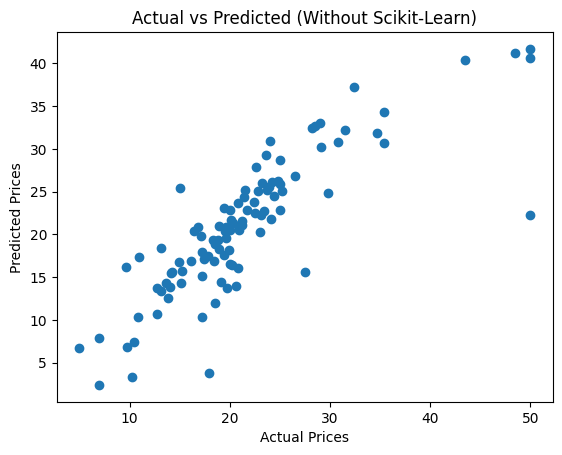

In [346]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Without Scikit-Learn)")

plt.show()

# WITHOUT SKLEARN

In [347]:
x = df_clean.drop(columns=['MEDV'], axis=1).values
y = df_clean['MEDV'].values

# Performing train test split on cleaned dataframe again
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [348]:
# Computes mean square error
# It first calcutates the prediction value using [X . w + b]
# then calculates the cost using (actual - prediction)^2

def compute_cost(X, y, w, b):

    m = X.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        cost = (y[i] - f_wb) ** 2
        cost_sum += cost

    total_cost = (1/(2*m)) * cost_sum

    return total_cost

In [349]:
def compute_gradient(X, y, w, b):

    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):

        f_wb = np.dot(X[i], w) + b
        error = f_wb - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i][j]

        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [350]:
import math
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):

    w = w_in.copy()
    b = b_in

    J_history = []

    for i in range(num_iters):

        dj_dw, dj_db = compute_gradient(X, y, w, b)

        # update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        J_history.append(cost)

        if i % (num_iters // 10) == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return w, b, J_history

In [351]:
# number of features
n = x_train.shape[1]

# initialize weights
w_init = np.zeros(n)
b_init = 0

iterations = 10000
alpha = 0.1

In [352]:
# Feature Scaling (Standardization)

X_mean = np.mean(x_train, axis=0)
X_std = np.std(x_train, axis=0)

x_train = (x_train - X_mean) / X_std
x_test = (x_test - X_mean) / X_std

In [353]:
w_final, b_final, J_hist = gradient_descent(
    x_train,
    y_train,
    w_init,
    b_init,
    alpha,
    iterations
)

print("Final weights:", w_final)
print("Final bias:", b_final)

Iteration 0, Cost: 237.44174502719105
Iteration 1000, Cost: 11.829735806993735
Iteration 2000, Cost: 11.829733723657151
Iteration 3000, Cost: 11.829733723624258
Iteration 4000, Cost: 11.829733723624248
Iteration 5000, Cost: 11.829733723624265
Iteration 6000, Cost: 11.829733723624258
Iteration 7000, Cost: 11.829733723624258
Iteration 8000, Cost: 11.829733723624258
Iteration 9000, Cost: 11.829733723624258
Final weights: [-1.03005052  0.50444995 -0.20050729  0.93855918 -1.57485316  3.13104142
 -0.41157171 -3.08314724  1.76695936 -1.46012577 -1.98993119  0.28468087
 -3.52442321]
Final bias: 22.796534653465354


In [354]:
y_pred = np.dot(x_test, w_final) + b_final

In [355]:
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_res = np.sum((y_test - y_pred)**2)

r2 = 1 - (ss_res/ss_total)

print("R2 Score (Manual Gradient Descent):", r2)

R2 Score (Manual Gradient Descent): 0.6902735603450811


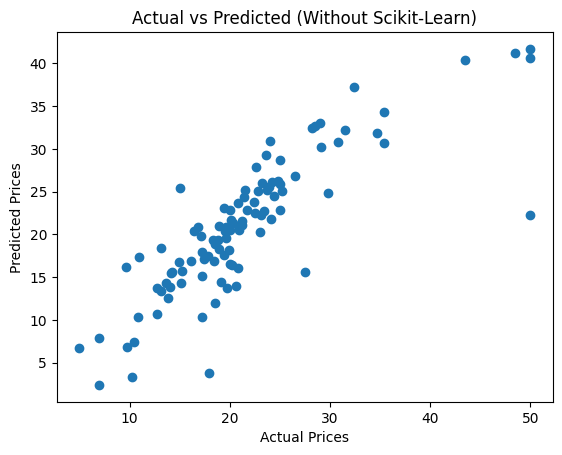

In [356]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Without Scikit-Learn)")

plt.show()


In [357]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Model Evaluate Metrics")
print(f"Mean Absolute Error (MAE): {MAE:.2f}")
print(f"Mean Squared Error (MSE): {MSE:.2f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.2f}")
print(f"R-squared Score (R²): {R2:.3f}")

Model Evaluate Metrics
Mean Absolute Error (MAE): 3.06
Mean Squared Error (MSE): 22.71
Root Mean Squared Error (RMSE): 4.77
R-squared Score (R²): 0.690
